In [1]:
# EXP1 = "G6sulfur"   # minuend
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"


In [2]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# User-defined metadata
# =========================

varname = "pr"
varname_T = "tas"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    # "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",}, : Data not available
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [3]:

# ================================================================
# Utility: year-range label per experiment, # Model/variable exceptions, etc
# ================================================================
def get_var_name(vname, model_name):
    """Handle model-specific variable name exceptions."""
    if vname == "huss":
        if model_name in ("CNRM-ESM2-1", "MPI-ESM1-2-LR", "IPSL-CM6A-LR"):
            return "huss"
    return vname
    
def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    ds_in = da.to_dataset(name='data')
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means

In [4]:
# # =========================
# # Physical constants
# # =========================
# Cp = 1005.0    # J kg-1 K-1
# Lv = 2.5e6     # J kg-1

# # =========================
# # THERMODYNAMIC-DYNAMIC DECOMPOSITION
# # =========================

# all_results = {}

# for model_name, model_meta in MODELS.items():

#     var = {}
#     var_by_year = {}

#     # ----------------------------
#     # 1) LOAD DATA FOR A MODEL: ALL EXPERIMENTS
#     # ----------------------------
#     for exp, meta in EXPERIMENTS.items():

#         # --- special-case ensemble override ---
#         if model_name == "CESM2-WACCM":
#             ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#         else:
#             ensemble = model_meta["ensemble"]

#         def make_base(vname):
#             return (
#                 CEDA_BASE
#                 / meta["project"]
#                 / model_meta["institution"]
#                 / model_name
#                 / meta["scenario"]
#                 / ensemble
#                 / "Amon"
#                 / vname
#                 / model_meta["grid"]
#                 / "latest"
#             )

#         base_uas = make_base("uas")   # surface zonal wind
#         base_vas = make_base("vas")   # surface meridional wind
#         base_huss = make_base("huss") # surface specific humidity

#         ######## ds for uas ############
#         print(f"Loading uas: {base_uas}")
#         if model_name == "CESM2-WACCM":
#             if meta["scenario"] == "G6sulfur":
#                 ds_uas = mf.open_files_CESM_G6sulfur(base_uas)
#             elif meta["scenario"] == "ssp585":
#                 ds_uas = mf.open_files_CESM_ssp585(base_uas)
#             else:
#                 ds_uas = mf.open_files(str(base_uas))
#         elif model_name == "IPSL-CM6A-LR":
#             if meta["scenario"] == "ssp585":
#                 ds_uas = mf.open_files_IPSL_ssp585(base_uas)
#             else:
#                 ds_uas = mf.open_files(str(base_uas))
#         else:
#             ds_uas = mf.open_files(str(base_uas))

#         ######## ds for vas ############
#         print(f"Loading vas: {base_vas}")
#         if model_name == "CESM2-WACCM":
#             if meta["scenario"] == "G6sulfur":
#                 ds_vas = mf.open_files_CESM_G6sulfur(base_vas)
#             elif meta["scenario"] == "ssp585":
#                 ds_vas = mf.open_files_CESM_ssp585(base_vas)
#             else:
#                 ds_vas = mf.open_files(str(base_vas))
#         elif model_name == "IPSL-CM6A-LR":
#             if meta["scenario"] == "ssp585":
#                 ds_vas = mf.open_files_IPSL_ssp585(base_vas)
#             else:
#                 ds_vas = mf.open_files(str(base_vas))
#         else:
#             ds_vas = mf.open_files(str(base_vas))

#         ######## ds for huss ############
#         print(f"Loading huss: {base_huss}")
#         if model_name == "CESM2-WACCM":
#             if meta["scenario"] == "G6sulfur":
#                 ds_huss = mf.open_files_CESM_G6sulfur(base_huss)
#             elif meta["scenario"] == "ssp585":
#                 ds_huss = mf.open_files_CESM_ssp585(base_huss)
#             else:
#                 ds_huss = mf.open_files(str(base_huss))
#         elif model_name == "IPSL-CM6A-LR":
#             if meta["scenario"] == "ssp585":
#                 ds_huss = mf.open_files_IPSL_ssp585(base_huss)
#             else:
#                 ds_huss = mf.open_files(str(base_huss))
#         else:
#             ds_huss = mf.open_files(str(base_huss))

#         # Read variables
#         da_uas = mf.read_var(ds_uas, "uas")
#         da_vas = mf.read_var(ds_vas, "vas")
#         da_huss = mf.read_var(ds_huss, get_var_name("huss", model_name))
        
#         # Drop unnecessary coordinates
#         da_uas = da_uas.drop_vars(["plev", "height"], errors="ignore")
#         da_vas = da_vas.drop_vars(["plev", "height"], errors="ignore")
#         da_huss = da_huss.drop_vars(["plev", "height"], errors="ignore")

#         print(f"  [{model_name}] {exp}: uas loaded {da_uas.sizes['time']} months")
#         print(f"  [{model_name}] {exp}: vas loaded {da_vas.sizes['time']} months")
#         print(f"  [{model_name}] {exp}: huss loaded {da_huss.sizes['time']} months")

#         # Store raw variables
#         var[exp] = {
#             "uas": da_uas,
#             "vas": da_vas,
#             "huss": da_huss
#         }

#     # ----------------------------
#     # 2) SEASONAL MEANS BY YEAR
#     # ----------------------------
#     for exp, var_dict in var.items():
#         t_start, t_end = _time_slice(exp)
        
#         var_by_year[exp] = {}
        
#         for vname in ["uas", "vas", "huss"]:
#             da = var_dict[vname]
#             da_sliced = da.sel(time=slice(t_start, t_end))
#             n_months = da_sliced.sizes['time']
#             print(f"  [{model_name}] {exp} {vname}: sliced to {n_months} months = "
#                   f"{n_months//12} years")

#             var_by_year[exp][vname] = {
#                 "SUM": mf.seasonal_mean_by_year_old(da_sliced, 6, 9),
#                 "WIN": mf.seasonal_mean_by_year_old(da_sliced, 11, 2),
#                 "ANN": mf.seasonal_mean_by_year_old(da_sliced, 1, 12)
#             }

#     # ----------------------------
#     # 3) CLIMATOLOGY
#     # ----------------------------
#     results = {}

#     for exp in var_by_year:
#         results[exp] = {}
#         for season in ["SUM", "WIN", "ANN"]:
#             results[exp][season] = {}
#             for vname in ["uas", "vas", "huss"]:
#                 da_year = var_by_year[exp][vname][season]
#                 results[exp][season][vname] = {
#                     "mean": da_year.mean(dim="year"),
#                     "sd":   da_year.std(dim="year"),
#                 }

#     # ----------------------------
#     # 4) THERMODYNAMIC-DYNAMIC DECOMPOSITION
#     # ----------------------------
#     if EXP1 in results and EXP2 in results:
        
#         thermo_dynamic = {}
        
#         for season in ["SUM", "WIN", "ANN"]:
            
#             # Get climatologies for each experiment
#             u1 = results[EXP1][season]["uas"]["mean"]
#             v1 = results[EXP1][season]["vas"]["mean"]
#             q1 = results[EXP1][season]["huss"]["mean"]
            
#             u2 = results[EXP2][season]["uas"]["mean"]
#             v2 = results[EXP2][season]["vas"]["mean"]
#             q2 = results[EXP2][season]["huss"]["mean"]
            
#             # Calculate changes
#             delta_u = u1 - u2
#             delta_v = v1 - v2
#             delta_q = q1 - q2
            
#             # Calculate gradients using central differences
#             # dq/dx (zonal gradient)
#             dq1_dx = q1.differentiate("lon") / (111320 * np.cos(np.deg2rad(q1.lat)))  # convert deg to meters
#             dq2_dx = q2.differentiate("lon") / (111320 * np.cos(np.deg2rad(q2.lat)))
            
#             # dq/dy (meridional gradient)
#             dq1_dy = q1.differentiate("lat") / 111320  # 1 degree lat ≈ 111.32 km
#             dq2_dy = q2.differentiate("lat") / 111320
            
#             # THERMODYNAMIC COMPONENT: -u2·∇(δq) - v2·∇(δq)
#             # Changes in moisture with fixed circulation
#             delta_q_dx = delta_q.differentiate("lon") / (111320 * np.cos(np.deg2rad(delta_q.lat)))
#             delta_q_dy = delta_q.differentiate("lat") / 111320
            
#             thermo = -(u2 * delta_q_dx + v2 * delta_q_dy)
            
#             # DYNAMIC COMPONENT: -δu·∇q2 - δv·∇q2
#             # Changes in circulation with fixed moisture
#             dyna = -(delta_u * dq2_dx + delta_v * dq2_dy)
            
#             # NONLINEAR (RESIDUAL) COMPONENT: -δu·∇(δq) - δv·∇(δq)
#             nonlin = -(delta_u * delta_q_dx + delta_v * delta_q_dy)
            
#             # Total change for verification: thermodynamic + dynamic + nonlinear
#             # Should approximately equal -[u1·∇q1 - u2·∇q2]
            
#             thermo_dynamic[season] = {
#                 "thermodynamic": thermo,
#                 "dynamic": dyna,
#                 "nonlinear": nonlin,
#                 "total_change": delta_q,  # For reference
#                 "moisture_advection_change": thermo + dyna + nonlin  # Should match -Δ(u·∇q + v·∇q)
#             }
        
#         results["thermo_dynamic_decomp"] = thermo_dynamic

#     all_results[model_name] = results

# print("\nThermodynamic-Dynamic decomposition complete!")
# print(f"Results stored in all_results[model_name]['thermo_dynamic_decomp'][season]")
# print("Available components: 'thermodynamic', 'dynamic', 'nonlinear', 'total_change', 'moisture_advection_change'")

In [5]:
# =========================
# Physical constants
# =========================
Cp = 1005.0    # J kg-1 K-1
Lv = 2.5e6     # J kg-1

# =========================
# THERMODYNAMIC-DYNAMIC DECOMPOSITION
# =========================

all_results = {}

for model_name, model_meta in MODELS.items():

    var = {}
    var_by_year = {}

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL: ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():

        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_uas = make_base("uas")   # surface zonal wind
        base_vas = make_base("vas")   # surface meridional wind
        base_huss = make_base("huss") # surface specific humidity

        ######## ds for uas ############
        print(f"Loading uas: {base_uas}")
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds_uas = mf.open_files_CESM_G6sulfur(base_uas)
            elif meta["scenario"] == "ssp585":
                ds_uas = mf.open_files_CESM_ssp585(base_uas)
            else:
                ds_uas = mf.open_files(str(base_uas))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds_uas = mf.open_files_IPSL_ssp585(base_uas)
            else:
                ds_uas = mf.open_files(str(base_uas))
        else:
            ds_uas = mf.open_files(str(base_uas))

        ######## ds for vas ############
        print(f"Loading vas: {base_vas}")
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds_vas = mf.open_files_CESM_G6sulfur(base_vas)
            elif meta["scenario"] == "ssp585":
                ds_vas = mf.open_files_CESM_ssp585(base_vas)
            else:
                ds_vas = mf.open_files(str(base_vas))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds_vas = mf.open_files_IPSL_ssp585(base_vas)
            else:
                ds_vas = mf.open_files(str(base_vas))
        else:
            ds_vas = mf.open_files(str(base_vas))

        ######## ds for huss ############
        print(f"Loading huss: {base_huss}")
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds_huss = mf.open_files_CESM_G6sulfur(base_huss)
            elif meta["scenario"] == "ssp585":
                ds_huss = mf.open_files_CESM_ssp585(base_huss)
            else:
                ds_huss = mf.open_files(str(base_huss))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds_huss = mf.open_files_IPSL_ssp585(base_huss)
            else:
                ds_huss = mf.open_files(str(base_huss))
        else:
            ds_huss = mf.open_files(str(base_huss))

        # Read variables
        da_uas = mf.read_var(ds_uas, "uas")
        da_vas = mf.read_var(ds_vas, "vas")
        da_huss = mf.read_var(ds_huss, get_var_name("huss", model_name))
        
        # Drop unnecessary coordinates
        da_uas = da_uas.drop_vars(["plev", "height"], errors="ignore")
        da_vas = da_vas.drop_vars(["plev", "height"], errors="ignore")
        da_huss = da_huss.drop_vars(["plev", "height"], errors="ignore")

        print(f"  [{model_name}] {exp}: uas loaded {da_uas.sizes['time']} months")
        print(f"  [{model_name}] {exp}: vas loaded {da_vas.sizes['time']} months")
        print(f"  [{model_name}] {exp}: huss loaded {da_huss.sizes['time']} months")

        # Store raw variables
        var[exp] = {
            "uas": da_uas,
            "vas": da_vas,
            "huss": da_huss
        }

    # ----------------------------
    # 2) SEASONAL MEANS BY YEAR
    # ----------------------------
    for exp, var_dict in var.items():
        t_start, t_end = _time_slice(exp)
        
        var_by_year[exp] = {}
        
        for vname in ["uas", "vas", "huss"]:
            da = var_dict[vname]
            da_sliced = da.sel(time=slice(t_start, t_end))
            n_months = da_sliced.sizes['time']
            print(f"  [{model_name}] {exp} {vname}: sliced to {n_months} months = "
                  f"{n_months//12} years")

            var_by_year[exp][vname] = {
                "SUM": mf.seasonal_mean_by_year_old(da_sliced, 6, 9),
                "WIN": mf.seasonal_mean_by_year_old(da_sliced, 11, 2),
                "ANN": mf.seasonal_mean_by_year_old(da_sliced, 1, 12)
            }

    # ----------------------------
    # 3) CLIMATOLOGY
    # ----------------------------
    results = {}

    for exp in var_by_year:
        results[exp] = {}
        for season in ["SUM", "WIN", "ANN"]:
            results[exp][season] = {}
            for vname in ["uas", "vas", "huss"]:
                da_year = var_by_year[exp][vname][season]
                results[exp][season][vname] = {
                    "mean": da_year.mean(dim="year"),
                    "sd":   da_year.std(dim="year"),
                }

    # ----------------------------
    # 4) THERMODYNAMIC-DYNAMIC DECOMPOSITION
    # ----------------------------
    # ----------------------------
    # 4) THERMODYNAMIC-DYNAMIC DECOMPOSITION
    # ----------------------------
    if EXP1 in results and EXP2 in results:
        
        thermo_dynamic = {}
        
        for season in ["SUM", "WIN", "ANN"]:
            
            # Get climatologies for each experiment
            u1 = results[EXP1][season]["uas"]["mean"]
            v1 = results[EXP1][season]["vas"]["mean"]
            q1 = results[EXP1][season]["huss"]["mean"]
            
            u2 = results[EXP2][season]["uas"]["mean"]
            v2 = results[EXP2][season]["vas"]["mean"]
            q2 = results[EXP2][season]["huss"]["mean"]
            
            print(f"\n  [{model_name}] {season}: Computing decomposition...")
            print(f"    Input shapes: u1={u1.shape}, v1={v1.shape}, q1={q1.shape}")
            print(f"                  u2={u2.shape}, v2={v2.shape}, q2={q2.shape}")
            
            # Check if coordinates exist
            if 'lat' not in q1.coords or 'lon' not in q1.coords:
                print(f"    ⚠️ WARNING: q1 missing lat/lon coordinates! Skipping {season}")
                continue
            
            # REGRID ALL VARIABLES TO A COMMON GRID (use q1's grid as reference)
            def regrid_to_q_grid(da, q_ref):
                """Regrid data array to match q's grid."""
                if da.shape == q_ref.shape and np.array_equal(da.lat.values, q_ref.lat.values) and np.array_equal(da.lon.values, q_ref.lon.values):
                    # Already on same grid
                    return da
                else:
                    # Need to regrid
                    return da.interp(lat=q_ref.lat, lon=q_ref.lon, method="linear")
            
            # Regrid u and v to q's grid
            u1 = regrid_to_q_grid(u1, q1)
            v1 = regrid_to_q_grid(v1, q1)
            u2 = regrid_to_q_grid(u2, q1)
            v2 = regrid_to_q_grid(v2, q1)
            # q2 should already be on same grid as q1, but check anyway
            q2 = regrid_to_q_grid(q2, q1)
            
            print(f"    After regridding: u1={u1.shape}, v1={v1.shape}, q1={q1.shape}")
            print(f"                      u2={u2.shape}, v2={v2.shape}, q2={q2.shape}")
            
            # Calculate changes
            delta_u = u1 - u2
            delta_v = v1 - v2
            delta_q = q1 - q2
            
            # Convert degrees to meters
            R_earth = 6371000  # meters
            
            # Get coordinate arrays - use q1's coordinates as reference
            lat = q1.lat.values
            lon = q1.lon.values
            
            if len(lat) < 2 or len(lon) < 2:
                print(f"    ⚠️ WARNING: Insufficient grid points! Skipping {season}")
                continue
            
            # Calculate grid spacing
            dlat_rad = np.deg2rad(lat[1] - lat[0])
            dlon_rad = np.deg2rad(lon[1] - lon[0])
            dy = R_earth * dlat_rad
            
            def calc_gradients(da):
                """Calculate both zonal and meridional gradients, returning numpy arrays."""
                values = da.values
                
                # Meridional gradient (constant dy)
                grad_y = np.gradient(values, axis=0, edge_order=2) / dy
                
                # Zonal gradient (dx varies with latitude)
                grad_x = np.zeros_like(values)
                for i, lat_val in enumerate(lat):
                    dx_at_lat = R_earth * np.cos(np.deg2rad(lat_val)) * dlon_rad
                    if dx_at_lat > 0:
                        grad_x[i, :] = np.gradient(values[i, :], edge_order=2) / dx_at_lat
                
                return grad_x, grad_y
            
            # Calculate gradients (returns numpy arrays)
            dq2_dx, dq2_dy = calc_gradients(q2)
            delta_q_dx, delta_q_dy = calc_gradients(delta_q)
            
            print(f"    Gradients computed: dq2_dx shape={dq2_dx.shape}")
            
            # Get numpy values for calculations
            u2_vals = u2.values
            v2_vals = v2.values
            delta_u_vals = delta_u.values
            delta_v_vals = delta_v.values
            
            print(f"    Array shapes before multiplication:")
            print(f"      u2_vals={u2_vals.shape}, delta_q_dx={delta_q_dx.shape}")
            
            # Calculate components using numpy arrays
            thermo_vals = -(u2_vals * delta_q_dx + v2_vals * delta_q_dy)
            dyna_vals = -(delta_u_vals * dq2_dx + delta_v_vals * dq2_dy)
            nonlin_vals = -(delta_u_vals * delta_q_dx + delta_v_vals * delta_q_dy)
            
            print(f"    Components computed: thermo_vals shape={thermo_vals.shape}")
            
            # Create DataArrays with explicit coordinates from q1
            thermo = xr.DataArray(
                thermo_vals,
                coords={'lat': q1.lat, 'lon': q1.lon},
                dims=['lat', 'lon'],
                name='thermodynamic'
            )
            
            dyna = xr.DataArray(
                dyna_vals,
                coords={'lat': q1.lat, 'lon': q1.lon},
                dims=['lat', 'lon'],
                name='dynamic'
            )
            
            nonlin = xr.DataArray(
                nonlin_vals,
                coords={'lat': q1.lat, 'lon': q1.lon},
                dims=['lat', 'lon'],
                name='nonlinear'
            )
            
            print(f"    ✓ Decomposition complete: thermo shape={thermo.shape}")
            
            # Store results
            thermo_dynamic[season] = {
                "thermodynamic": thermo,
                "dynamic": dyna,
                "nonlinear": nonlin,
                "total_change": delta_q,
                "moisture_advection_change": thermo + dyna + nonlin
            }
        
        results["thermo_dynamic_decomp"] = thermo_dynamic

    all_results[model_name] = results
        
print("\nThermodynamic-Dynamic decomposition complete!")
print(f"Results stored in all_results[model_name]['thermo_dynamic_decomp'][season]")
print("Available components: 'thermodynamic', 'dynamic', 'nonlinear', 'total_change', 'moisture_advection_change'")

Loading uas: /badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/uas/gn/latest
Loading vas: /badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/vas/gn/latest
Loading huss: /badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/huss/gn/latest
  [UKESM1-0-LL] G6sulfur: uas loaded 972 months
  [UKESM1-0-LL] G6sulfur: vas loaded 972 months
  [UKESM1-0-LL] G6sulfur: huss loaded 972 months
Loading uas: /badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/uas/gn/latest
Loading vas: /badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/vas/gn/latest
Loading huss: /badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/huss/gn/latest
  [UKESM1-0-LL] SSP245: uas loaded 1032 months
  [UKESM1-0-LL] SSP245: vas loaded 1032 months
  [UKESM1-0-LL] SSP245: huss loaded 1032 months
  [UKESM1-0-LL] G6sulfur uas: sliced to 960 months = 80 years
  [UKESM1-0-LL] G6sulfur vas: sliced to 960 months = 80 

In [6]:
def compute_regional_map_decomp(
    all_results,
    exp1,
    exp2,
    component="thermodynamic",  # "thermodynamic", "dynamic", "nonlinear", "total_change"
    trop_bound=50,
    land_mask=None,
    agreement_threshold=3,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import cartopy.io.shapereader as shpreader
    import xarray as xr
    import warnings
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    label1   = _exp_year_label(exp1)
    label2   = _exp_year_label(exp2)
    var_name = f"TH_DY_map_{component}_{exp1}{label1}_minus_{exp2}{label2}"

    # ------------------------------------------------------------------ #
    # 1.  Build per-model fields for the specified component
    # ------------------------------------------------------------------ #
    delta_list = []

    for model_name, results in all_results.items():
        if "thermo_dynamic_decomp" not in results:
            warnings.warn(f"Model '{model_name}' has no 'thermo_dynamic_decomp' — skipped.")
            continue

        delta_by_season = {}
        for season in ("SUM", "WIN"):
            if season not in results["thermo_dynamic_decomp"]:
                warnings.warn(f"Model '{model_name}' missing season '{season}' — skipped.")
                continue
            if component not in results["thermo_dynamic_decomp"][season]:
                warnings.warn(f"Model '{model_name}' missing component '{component}' in season '{season}' — skipped.")
                continue
            
            delta_by_season[season] = results["thermo_dynamic_decomp"][season][component]

        if len(delta_by_season) < 2:
            warnings.warn(f"Model '{model_name}' missing required seasons — skipped.")
            continue

        da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))

        lat      = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)   # NH=SUM, SH=WIN
        delta_list.append(stitched)

    if not delta_list:
        raise ValueError(f"No models with thermo_dynamic_decomp for component '{component}' found.")

    n_models = len(delta_list)
    stacked  = xr.concat(delta_list, dim="model")

    # ------------------------------------------------------------------ #
    # 2.  Multi-model mean and stippling mask
    # ------------------------------------------------------------------ #

    delta_mean = stacked.mean(dim="model").squeeze()

    sign_mean    = np.sign(delta_mean.values)
    sign_models  = np.sign(stacked.values)
    n_agree      = np.sum(sign_models == sign_mean[np.newaxis, :, :], axis=0)
    stipple_mask = n_agree >= agreement_threshold

    lat  = delta_mean.lat.values
    lon  = delta_mean.lon.values
    data = delta_mean.values
    LON, LAT = np.meshgrid(lon, lat)

    # ------------------------------------------------------------------ #
    # 3.  Plot
    # ------------------------------------------------------------------ #
    if plot:
        vmax = float(np.nanpercentile(np.abs(data), 98))
        vmin = -vmax
        levels = np.linspace(-vmax, vmax, 21)

        fig, ax = plt.subplots(figsize=(10, 5),
                               subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.set_global()

        im = ax.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())

        # Stippling
        stip_lat_flat = LAT[stipple_mask].ravel()[::2]
        stip_lon_flat = LON[stipple_mask].ravel()[::2]
        ax.scatter(stip_lon_flat, stip_lat_flat,
                   s=1.5, color="black", alpha=0.5, zorder=5)

        # Coastlines
        try:
            shpfilename = shpreader.natural_earth(
                resolution="110m", category="physical", name="coastline"
            )
            reader = shpreader.Reader(shpfilename)
            for geom in reader.geometries():
                if hasattr(geom, "geoms"):
                    for g in geom.geoms:
                        ax.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
                else:
                    ax.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
        except Exception:
            pass

        cbar = plt.colorbar(im, ax=ax, orientation="horizontal", 
                            pad=0.05, shrink=1.0, aspect=40)

        # Component-specific label
        component_labels = {
            "thermodynamic": "Thermodynamic Component: -u₂·∇(δq)",
            "dynamic": "Dynamic Component: -δu·∇q₂",
            "nonlinear": "Nonlinear Component: -δu·∇(δq)",
            "total_change": "Total Moisture Change: δq",
            "moisture_advection_change": "Total Moisture Advection Change"
        }
        
        cbar_label = component_labels.get(component, component)
        cbar.set_label(f"{cbar_label}  ({exp1} − {exp2})  [kg/kg/s]", fontsize=10)

        # Equator line
        ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
        ax.set_extent([float(lon.min()), float(lon.max()),
                       float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
        ax.set_aspect('auto')
    
        ax.set_xticks(np.arange(np.floor(float(lon.min())),
                                np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(np.floor(float(lat.min())),
                                np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=8)

        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
        
        title_text = component_labels.get(component, component.replace("_", " ").title())
        ax.set_title(
            f"Multi-model mean: {title_text}\n"
            f"({exp1} − {exp2})  |  NH: JJAS, SH: NDJF  |  "
            f"stippling = {agreement_threshold}/{n_models} model sign agreement",
            fontsize=11
        )
        ax.grid(True, linewidth=0.3, alpha=0.4)

        # Bombardi and Boos 2021 regions
        regions = {
            'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
            'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
            'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
            'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
            'India':        {'lon': (73,  87),   'lat': (15,    27)},
            'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
        }
        for name, coords in regions.items():
            lon0, lon1 = coords['lon']
            lat0, lat1 = coords['lat']
            rect = mpatches.Rectangle(
                (lon0, lat0), lon1-lon0, lat1-lat0,
                linewidth=1.2, edgecolor='black', facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax.add_patch(rect)
            ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
                    fontsize=8, ha='center', va='top',
                    transform=ccrs.PlateCarree())

        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    print(f"Returning → {var_name}")
    return delta_mean, stipple_mask

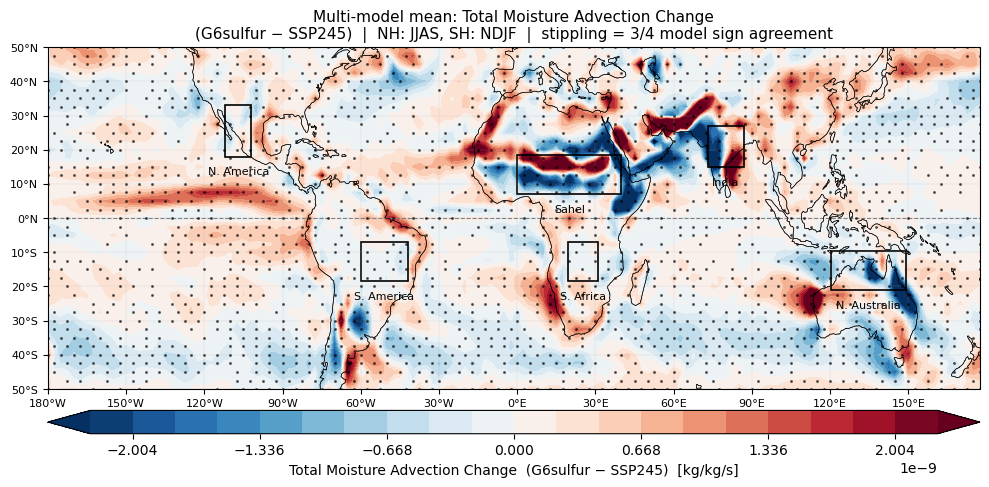

Figure saved → TH_DY_map_moisture_advection_change_G6sulfur20212100_minus_SSP24520212100.png
Returning → TH_DY_map_moisture_advection_change_G6sulfur20212100_minus_SSP24520212100


In [7]:
# Usage example:
# Plot thermodynamic component
delta_thermo, stipple_thermo = compute_regional_map_decomp(
    all_results, 
    exp1=EXP1, 
    exp2=EXP2,
    component="moisture_advection_change", 
    plot=True,
    save_fig=True,          # <-- REQUIRED
)

# Later you can plot other components:
# delta_dyna, stipple_dyna = compute_regional_map_decomp(
#     all_results, exp1=EXP1, exp2=EXP2, component="dynamic", plot=True
# )
# delta_nonlin, stipple_nonlin = compute_regional_map_decomp(
#     all_results, exp1=EXP1, exp2=EXP2, component="nonlinear", plot=True
# )

# DEBUGGING steps

In [8]:
# Diagnostic code to see what's in all_results
for model_name, results in all_results.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    
    if "thermo_dynamic_decomp" in results:
        print("✓ Has thermo_dynamic_decomp")
        for season in ["SUM", "WIN", "ANN"]:
            if season in results["thermo_dynamic_decomp"]:
                print(f"  ✓ Season {season}:")
                for comp in results["thermo_dynamic_decomp"][season].keys():
                    da = results["thermo_dynamic_decomp"][season][comp]
                    print(f"      {comp}: shape={da.shape}, dims={da.dims}")
                    if hasattr(da, 'lat') and hasattr(da, 'lon'):
                        print(f"         lat range: {da.lat.min().values} to {da.lat.max().values}")
                        print(f"         lon range: {da.lon.min().values} to {da.lon.max().values}")
                    else:
                        print(f"         ⚠ Missing lat/lon coordinates!")
                        print(f"         coords: {list(da.coords.keys())}")
            else:
                print(f"  ✗ Missing season {season}")
    else:
        print("✗ No thermo_dynamic_decomp found")
    
    break  # Just check first model for now


Model: UKESM1-0-LL
✓ Has thermo_dynamic_decomp
  ✓ Season SUM:
      thermodynamic: shape=(144, 192), dims=('lat', 'lon')
         lat range: -89.375 to 89.375
         lon range: 0.9375 to 359.0625
      dynamic: shape=(144, 192), dims=('lat', 'lon')
         lat range: -89.375 to 89.375
         lon range: 0.9375 to 359.0625
      nonlinear: shape=(144, 192), dims=('lat', 'lon')
         lat range: -89.375 to 89.375
         lon range: 0.9375 to 359.0625
      total_change: shape=(144, 192), dims=('lat', 'lon')
         lat range: -89.375 to 89.375
         lon range: 0.9375 to 359.0625
      moisture_advection_change: shape=(144, 192), dims=('lat', 'lon')
         lat range: -89.375 to 89.375
         lon range: 0.9375 to 359.0625
  ✓ Season WIN:
      thermodynamic: shape=(144, 192), dims=('lat', 'lon')
         lat range: -89.375 to 89.375
         lon range: 0.9375 to 359.0625
      dynamic: shape=(144, 192), dims=('lat', 'lon')
         lat range: -89.375 to 89.375
         lon

In [9]:
# def compute_decomp_bar(
#     all_results,
#     exp1,
#     exp2,
#     component="thermodynamic",  # "thermodynamic", "dynamic", "nonlinear", "total_change"
#     trop_bound=50,
#     save_pkl=True,
#     pkl_path=None,
# ):
#     """
#     Compute regional averages of decomposition components over monsoon boxes.
    
#     Parameters
#     ----------
#     all_results : dict
#         Dictionary of model results from decomposition
#     exp1, exp2 : str
#         Experiment names to compare
#     component : str
#         Which component to analyze
#     trop_bound : int
#         Latitude bound for regridding
#     save_pkl : bool
#         Whether to save results to pickle
#     pkl_path : str or None
#         Path to save pickle file (auto-generated if None)
    
#     Returns
#     -------
#     regional_data : dict
#         Dictionary with regional averages per model and region
#     """
#     import numpy as np
#     import xarray as xr
#     import warnings
#     import pickle
#     from pathlib import Path

#     label1 = _exp_year_label(exp1)
#     label2 = _exp_year_label(exp2)
    
#     # Bombardi and Boos 2021 monsoon regions
#     regions = {
#         'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
#         'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
#         'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
#         'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
#         'India':        {'lon': (73,  87),   'lat': (15,    27)},
#         'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
#     }
    
#     # ------------------------------------------------------------------ #
#     # 1. Build per-model delta fields (exp1 - exp2)
#     # ------------------------------------------------------------------ #
#     regional_data = {
#         'metadata': {
#             'exp1': exp1,
#             'exp2': exp2,
#             'component': component,
#             'regions': regions
#         },
#         'models': {}
#     }
    
#     for model_name, results in all_results.items():
#         if "thermo_dynamic_decomp" not in results:
#             warnings.warn(f"Model '{model_name}' has no 'thermo_dynamic_decomp' — skipped.")
#             continue

#         model_regional = {}
        
#         # Process each season
#         for season in ("SUM", "WIN"):
#             if season not in results["thermo_dynamic_decomp"]:
#                 warnings.warn(f"Model '{model_name}' missing season '{season}' — skipped.")
#                 continue
#             if component not in results["thermo_dynamic_decomp"][season]:
#                 warnings.warn(f"Model '{model_name}' missing component '{component}' in season '{season}' — skipped.")
#                 continue
            
#             # Get the component data
#             da = results["thermo_dynamic_decomp"][season][component]
            
#             # Regrid to common grid and roll longitude
#             da_regrid = roll_lon(regrid_to_common(da, target_lat=trop_bound))
            
#             # Calculate regional averages
#             season_regional = {}
#             for region_name, coords in regions.items():
#                 lon0, lon1 = coords['lon']
#                 lat0, lat1 = coords['lat']
                
#                 # Select region
#                 da_region = da_regrid.sel(
#                     lat=slice(lat0, lat1),
#                     lon=slice(lon0, lon1)
#                 )
                
#                 # Area-weighted mean
#                 weights = np.cos(np.deg2rad(da_region.lat))
#                 weighted_mean = (da_region * weights).sum(dim=['lat', 'lon']) / weights.sum()
                
#                 season_regional[region_name] = float(weighted_mean.values)
            
#             model_regional[season] = season_regional
        
#         regional_data['models'][model_name] = model_regional
#         print(f"  [{model_name}] Regional averages computed for {component}")
    
#     # ------------------------------------------------------------------ #
#     # 2. Calculate multi-model statistics
#     # ------------------------------------------------------------------ #
#     mm_stats = {}
    
#     for season in ("SUM", "WIN"):
#         season_stats = {}
        
#         for region_name in regions.keys():
#             # Collect values across models
#             values = []
#             for model_name, model_data in regional_data['models'].items():
#                 if season in model_data and region_name in model_data[season]:
#                     values.append(model_data[season][region_name])
            
#             if len(values) > 0:
#                 season_stats[region_name] = {
#                     'mean': float(np.mean(values)),
#                     'std': float(np.std(values)),
#                     'min': float(np.min(values)),
#                     'max': float(np.max(values)),
#                     'n_models': len(values),
#                     'values': values  # Individual model values
#                 }
        
#         mm_stats[season] = season_stats
    
#     regional_data['multi_model'] = mm_stats
    
#     # ------------------------------------------------------------------ #
#     # 3. Save to pickle
#     # ------------------------------------------------------------------ #
#     if save_pkl:
#         if pkl_path is None:
#             pkl_path = f"regional_decomp_{component}_{exp1}{label1}_minus_{exp2}{label2}.pkl"
        
#         pkl_path = Path(pkl_path)
#         with open(pkl_path, 'wb') as f:
#             pickle.dump(regional_data, f)
#         print(f"\n✓ Regional data saved to: {pkl_path}")
    
#     # ------------------------------------------------------------------ #
#     # 4. Print summary
#     # ------------------------------------------------------------------ #
#     print(f"\n{'='*70}")
#     print(f"REGIONAL SUMMARY: {component} ({exp1} - {exp2})")
#     print(f"{'='*70}")
    
#     for season in ("SUM", "WIN"):
#         print(f"\n{season} (Summer hemisphere):")
#         print(f"  {'Region':<15} {'Mean':<12} {'Std':<12} {'N models':<10}")
#         print(f"  {'-'*15} {'-'*12} {'-'*12} {'-'*10}")
        
#         if season in mm_stats:
#             for region_name, stats in mm_stats[season].items():
#                 print(f"  {region_name:<15} {stats['mean']:>11.2e} {stats['std']:>11.2e} {stats['n_models']:>10}")
    
#     return regional_data


# # Usage example:
# # regional_thermo = compute_decomp_bar(
# #     all_results,
# #     exp1=EXP1,
# #     exp2=EXP2,
# #     component="thermodynamic",
# #     save_pkl=True
# # )
# #
# # regional_dyna = compute_decomp_bar(
# #     all_results,
# #     exp1=EXP1,
# #     exp2=EXP2,
# #     component="dynamic",
# #     save_pkl=True
# # )

In [10]:
def compute_decomp_bar(
    all_results,
    exp1,
    exp2,
    component="thermodynamic",  # "thermodynamic", "dynamic", "nonlinear", "total_change"
    trop_bound=50,
    land_mask=None,
    plot=True,
    save_pkl=True,
    pkl_path=None,
    save_fig=False,
    fig_path=None,
):
    """
    Compute regional averages of decomposition components over monsoon boxes.
    
    Parameters
    ----------
    all_results : dict
        Dictionary of model results from decomposition
    exp1, exp2 : str
        Experiment names to compare
    component : str
        Which component to analyze
    trop_bound : int
        Latitude bound for regridding
    land_mask : xarray.DataArray or None
        Boolean land mask. If None, built from regionmask.
    plot : bool
        Whether to create bar plot
    save_pkl : bool
        Whether to save results to pickle
    pkl_path : str or None
        Path to save pickle file (auto-generated if None)
    save_fig : bool
        Whether to save figure
    fig_path : str or None
        Path to save figure (auto-generated if None)
    
    Returns
    -------
    bar_data : dict
        Dictionary with regional averages per model and region
    var_name : str
        Variable name string
    """
    import numpy as np
    import xarray as xr
    import warnings
    import pickle
    from pathlib import Path
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    label1 = _exp_year_label(exp1)
    label2 = _exp_year_label(exp2)
    var_name = f"bar_data_decomp_{component}_{exp1}{label1}_minus_{exp2}{label2}"
    
    # ------------------------------------------------------------------ #
    # 1. Build per-model delta fields (exp1 - exp2)
    # ------------------------------------------------------------------ #
    delta_list = []
    
    for model_name, results in all_results.items():
        if "thermo_dynamic_decomp" not in results:
            warnings.warn(f"Model '{model_name}' has no 'thermo_dynamic_decomp' — skipped.")
            continue

        delta_by_season = {}
        for season in ("SUM", "WIN"):
            if season not in results["thermo_dynamic_decomp"]:
                warnings.warn(f"Model '{model_name}' missing season '{season}' — skipped.")
                continue
            if component not in results["thermo_dynamic_decomp"][season]:
                warnings.warn(f"Model '{model_name}' missing component '{component}' — skipped.")
                continue
            
            delta_by_season[season] = results["thermo_dynamic_decomp"][season][component]

        if len(delta_by_season) < 2:
            warnings.warn(f"Model '{model_name}' missing required seasons — skipped.")
            continue

        da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))

        lat = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)  # NH=SUM, SH=WIN
        delta_list.append(stitched)

    if not delta_list:
        raise ValueError(f"No models with thermo_dynamic_decomp for component '{component}' found.")

    stacked = xr.concat(delta_list, dim="model")  # (model, lat, lon)
    lat = stacked.lat.values
    lon = stacked.lon.values

    # ------------------------------------------------------------------ #
    # 2. Land / ocean mask
    # ------------------------------------------------------------------ #
    if land_mask is None:
        try:
            import regionmask
            land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            mask_np = land_110.mask(lon, lat)
            land_mask_da = xr.DataArray(~np.isnan(mask_np.values),
                                        dims=["lat", "lon"],
                                        coords={"lat": lat, "lon": lon})
        except ImportError:
            warnings.warn("regionmask not found — using all-ocean proxy.")
            land_mask_da = xr.DataArray(np.zeros((len(lat), len(lon)), dtype=bool),
                                        dims=["lat", "lon"],
                                        coords={"lat": lat, "lon": lon})
    else:
        land_mask_da = land_mask.interp(lat=lat, lon=lon, method="nearest") > 0.5

    ocean_mask_da = ~land_mask_da

    # ------------------------------------------------------------------ #
    # 3. Monsoon region boxes
    # ------------------------------------------------------------------ #
    regions = {
        "N. America":   {"lon": (248, 258),   "lat": (18,    33)},
        "S. America":   {"lon": (300, 318),   "lat": (-18.5, -7)},
        "Sahel":        {"lon": (0,   40),    "lat": (7,   18.5)},
        "S. Africa":    {"lon": (19.5, 31),   "lat": (-18.5, -7)},
        "India":        {"lon": (73,  87),    "lat": (15,    27)},
        "N. Australia": {"lon": (120.5, 149), "lat": (-21,  -9.5)},
    }

    # ------------------------------------------------------------------ #
    # 4. Area-weighted means
    # ------------------------------------------------------------------ #
    weights = np.cos(np.deg2rad(lat))
    weights_da = xr.DataArray(weights, dims=["lat"], coords={"lat": lat})

    def area_mean(data_3d, mask_2d):
        masked = data_3d.where(mask_2d)
        w = weights_da.where(mask_2d)
        return (masked * w).sum(["lat", "lon"]) / w.sum(["lat", "lon"])

    def to_180(l):
        return ((l + 180) % 360) - 180

    def box_mask(lon_range, lat_range):
        lon0, lon1 = to_180(lon_range[0]), to_180(lon_range[1])
        lat0, lat1 = lat_range
        lon_da, lat_da = stacked.lon, stacked.lat
        if lon0 <= lon1:
            lon_sel = (lon_da >= lon0) & (lon_da <= lon1)
        else:
            lon_sel = (lon_da >= lon0) | (lon_da <= lon1)
        return lon_sel & (lat_da >= lat0) & (lat_da <= lat1)

    labels = []
    means = []
    colors = []
    per_model_all = []

    land_ocean = [("Land",  land_mask_da,  "#E07B3A"),
                  ("Ocean", ocean_mask_da, "#3A7BE0")]
    region_colors = ["#D45F8B", "#8B5FD4", "#5FD4A0",
                     "#D4A05F", "#5FAFD4", "#A0D45F"]

    for label, mask, color in land_ocean:
        pm = area_mean(stacked, mask).values
        labels.append(label)
        means.append(float(np.nanmean(pm)))
        colors.append(color)
        per_model_all.append(pm)

    for (rname, coords), rcol in zip(regions.items(), region_colors):
        bmask = box_mask(coords["lon"], coords["lat"])
        pm = area_mean(stacked, bmask).values
        labels.append(rname)
        means.append(float(np.nanmean(pm)))
        colors.append(rcol)
        per_model_all.append(pm)

    means = np.array(means)
    x = np.arange(len(labels))

    # ------------------------------------------------------------------ #
    # 5. Plot (optional)
    # ------------------------------------------------------------------ #
    fig = None
    if plot:
        # Component-specific labels
        component_labels = {
            "thermodynamic": "Thermodynamic: -u₂·∇(δq)",
            "dynamic": "Dynamic: -δu·∇q₂",
            "nonlinear": "Nonlinear: -δu·∇(δq)",
            "total_change": "Total Moisture Change: δq",
            "moisture_advection_change": "Total Advection Change"
        }
        
        title_label = component_labels.get(component, component.replace("_", " ").title())
        
        fig, ax = plt.subplots(figsize=(11, 5))

        ax.bar(x, means, color=colors, edgecolor="k",
               linewidth=0.7, alpha=0.85, zorder=3)

        rng = np.random.default_rng(42)
        n_models = len(delta_list)
        for i, pm in enumerate(per_model_all):
            jitter = rng.uniform(-0.18, 0.18, size=len(pm))
            ax.scatter(x[i] + jitter, pm, color="k", s=20,
                       zorder=5, alpha=0.6, linewidths=0.4, edgecolors="white")

        ax.axhline(0, color="k", linewidth=0.8, linestyle="--", zorder=2)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel(
            f"{title_label} (kg kg$^{{-1}}$ s$^{{-1}}$)",
            fontsize=10)
        ax.set_title(
            f"Multi-model mean: {title_label}\n"
            f"({exp1} − {exp2})  |  NH: JJAS, SH: NDJF  |  "
            f"dots = individual models ({n_models} models)",
            fontsize=11)
        ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7, zorder=1)

        legend_patches = [
            mpatches.Patch(color="#E07B3A", label="Land"),
            mpatches.Patch(color="#3A7BE0", label="Ocean"),
            mpatches.Patch(color="grey",    label="Monsoon regions"),
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="k",
                       markersize=6, alpha=0.6, label="Individual models"),
        ]
        ax.legend(handles=legend_patches, fontsize=9, loc="upper right")
        
        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    # ------------------------------------------------------------------ #
    # 6. Package and save to pickle
    # ------------------------------------------------------------------ #
    bar_data = {
        "labels": labels,
        "means": means,
        "colors": colors,
        "per_model_all": per_model_all,
        "component": component,
        "exp1": exp1,
        "exp2": exp2,
    }

    if save_pkl:
        if pkl_path is None:
            pkl_path = f"regional_decomp_{component}_{exp1}{label1}_minus_{exp2}{label2}.pkl"
        
        pkl_path = Path(pkl_path)
        with open(pkl_path, 'wb') as f:
            pickle.dump(bar_data, f)
        print(f"\n✓ Regional data saved to: {pkl_path}")

    print(f"Returning → {var_name}")
    return bar_data, var_name


# Usage examples:
# bar_thermo, var_thermo = compute_decomp_bar(
#     all_results,
#     exp1=EXP1,
#     exp2=EXP2,
#     component="thermodynamic",
#     plot=True,
#     save_pkl=True
# )
#
# bar_dyna, var_dyna = compute_decomp_bar(
#     all_results,
#     exp1=EXP1,
#     exp2=EXP2,
#     component="dynamic",
#     plot=True,
#     save_pkl=True
# )

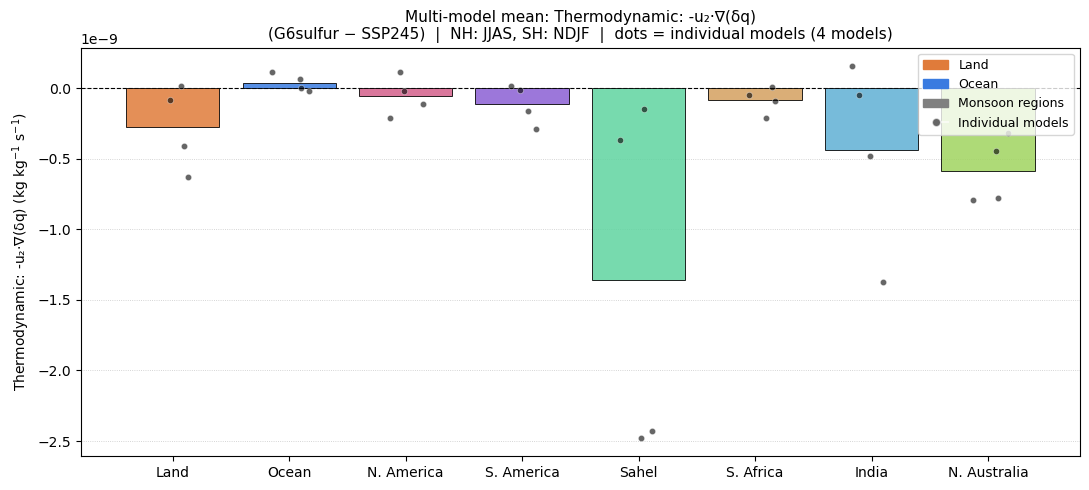


✓ Regional data saved to: regional_decomp_thermodynamic_G6sulfur20212100_minus_SSP24520212100.pkl
Returning → bar_data_decomp_thermodynamic_G6sulfur20212100_minus_SSP24520212100


In [11]:
# Usage example:
regional_thermo = compute_decomp_bar(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    component="thermodynamic",
    plot=True,
    save_pkl=True
)

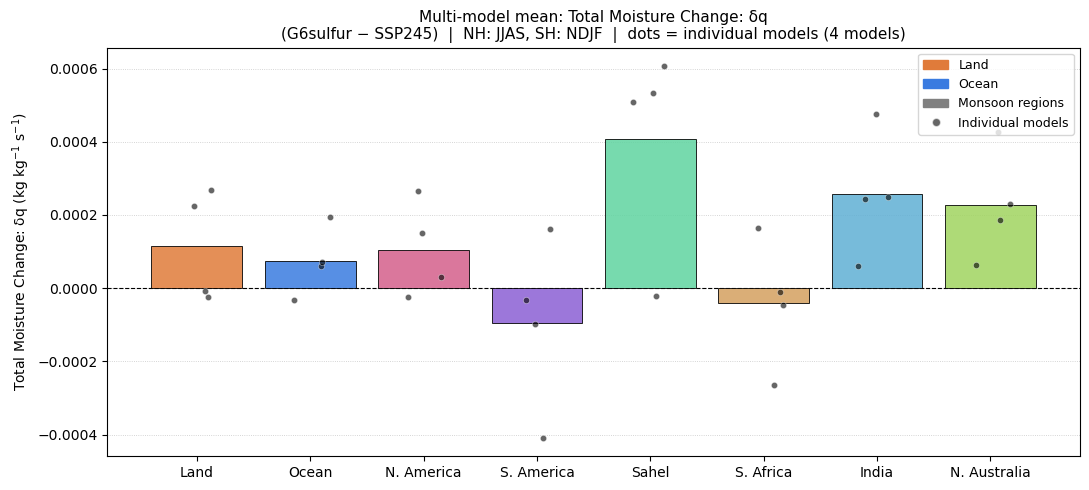


✓ Regional data saved to: regional_decomp_total_change_G6sulfur20212100_minus_SSP24520212100.pkl
Returning → bar_data_decomp_total_change_G6sulfur20212100_minus_SSP24520212100


In [12]:
# Usage example:
regional_thermo = compute_decomp_bar(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    component="total_change",
    plot=True,
    save_pkl=True
)

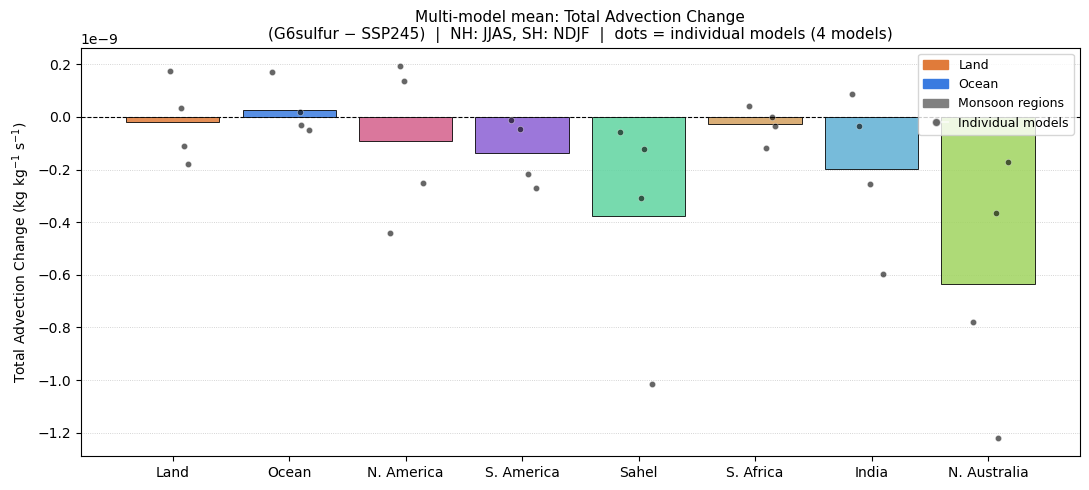


✓ Regional data saved to: regional_decomp_moisture_advection_change_G6sulfur20212100_minus_SSP24520212100.pkl
Returning → bar_data_decomp_moisture_advection_change_G6sulfur20212100_minus_SSP24520212100


In [13]:

# Usage example:
regional_thermo = compute_decomp_bar(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    component="moisture_advection_change",
    plot=True,
    save_pkl=True
)

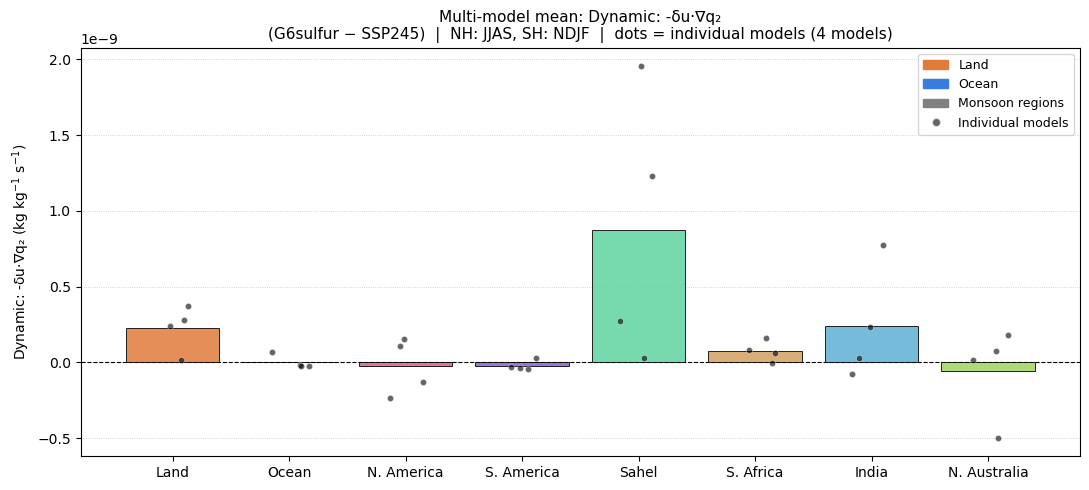


✓ Regional data saved to: regional_decomp_dynamic_G6sulfur20212100_minus_SSP24520212100.pkl
Returning → bar_data_decomp_dynamic_G6sulfur20212100_minus_SSP24520212100


In [14]:

# Usage example:
regional_thermo = compute_decomp_bar(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    component="dynamic",
    plot=True,
    save_pkl=True
)

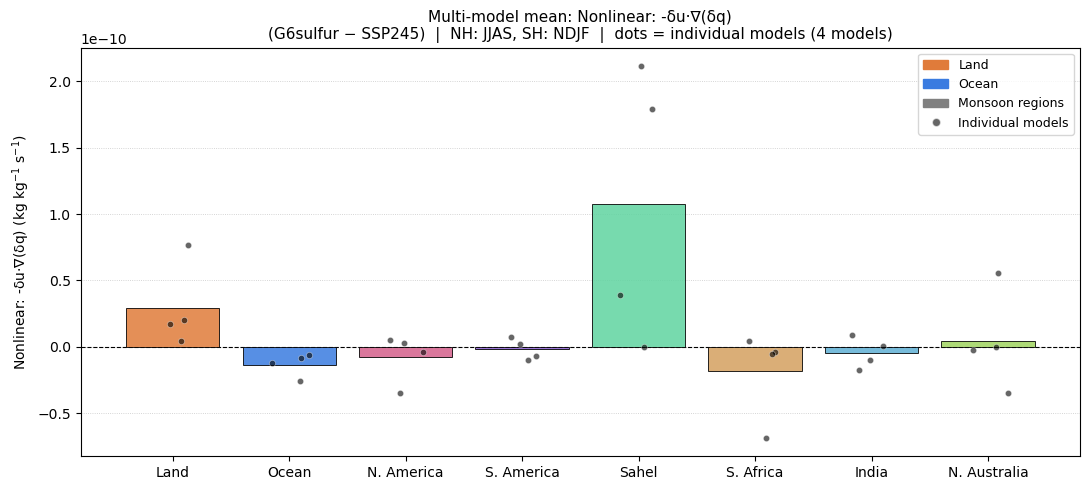


✓ Regional data saved to: regional_decomp_nonlinear_G6sulfur20212100_minus_SSP24520212100.pkl
Returning → bar_data_decomp_nonlinear_G6sulfur20212100_minus_SSP24520212100


In [15]:

# Usage example:
regional_thermo = compute_decomp_bar(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    component="nonlinear",
    plot=True,
    save_pkl=True
)

In [16]:
# The pickle file contains
###########################
# {
#     'metadata': {
#         'exp1': 'G6sulfur',
#         'exp2': 'SSP245',
#         'component': 'thermodynamic',
#         'regions': {...}  # region definitions
#     },
#     'models': {
#         'UKESM1-0-LL': {
#             'SUM': {'N. America': 1.23e-8, 'India': 4.56e-8, ...},
#             'WIN': {'S. America': -2.34e-8, 'S. Africa': 1.11e-8, ...}
#         },
#         'CNRM-ESM2-1': {...},
#         ...
#     },
#     'multi_model': {
#         'SUM': {
#             'N. America': {'mean': 1.5e-8, 'std': 2.3e-9, 'n_models': 5, 'values': [...]},
#             'India': {...},
#             ...
#         },
#         'WIN': {...}
#     }
# }

# To open the pickle file 
##########################
# import pickle
# with open('regional_decomp_thermodynamic_G6sulfur20212100_minus_SSP24520212100.pkl', 'rb') as f:
#     data = pickle.load(f)

# # Access multi-model mean for India in summer
# india_summer_mean = data['multi_model']['SUM']['India']['mean']